# MKA-MLF, Lab_08 - RNN

Recurrent Neural Networks, are a class of artificial neural networks designed to recognize patterns in sequences of data, such as text, genomes, handwriting, or spoken words. Unlike traditional neural networks, which assume all inputs (and outputs) are independent of each other, RNNs are designed to recognize sequential or temporal patterns, making them especially suited for tasks like language modeling, speech recognition, and time series prediction.

## Exercise 1 - Time Series Forecasting

### 1.0 Import Libraries

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from keras.layers import Dense, Flatten, SimpleRNN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam

### 1.1 Generating dataset

In [31]:
def generate_time_series(batch_size, n_steps):
  freq1, freq2, offsets1, offsets2 = np.random.rand(4, batch_size, 1)
  time = np.linspace(0,1,n_steps)

  series = 0.5 * np.sin((time - offsets1) * (freq1*10 + 10))
  series += 0.2 * np.sin((time - offsets2) * (freq2*20 + 20))
  series += 0.1 * (np.random.rand(batch_size, n_steps)- 0.5)
  return series[..., np.newaxis].astype(np.float32)

In [32]:
data_size = 10000
n_steps = 50
np.random.seed(0)

series = generate_time_series(data_size, n_steps + 1)

### 1.2 Train/Valid/Test split

In [33]:
X_train, y_train = series[:7000, :n_steps], series[:7000, -1]
X_valid, y_valid = series[7000:9000, :n_steps], series[7000:9000, -1]
X_test, y_test = series[9000:, :n_steps], series[9000:, -1]

In [34]:
no_training_epochs = 5

### 1.3 Data examination

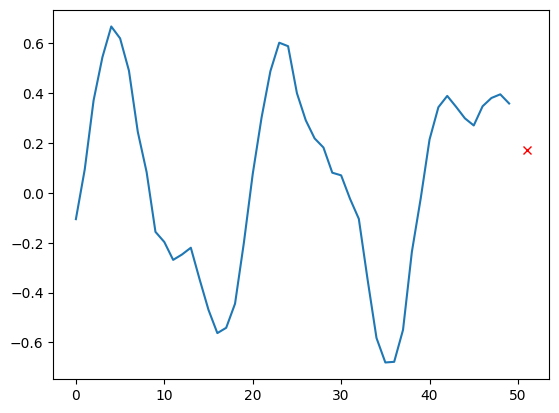

In [35]:
plt.figure()
plt.plot(X_train[0])
plt.plot(n_steps+1, y_train[0], 'rx')

### 1.4 Simple Linear model

In [36]:
# Model definition
model_linear = Sequential()
model_linear.add(Flatten(input_shape=(50,1)))
model_linear.add(Dense(1, activation = None))

In [37]:
# Model building

learning_rate = 0.001
optimizer = Adam(learning_rate)
model_linear.compile(loss='mean_squared_error', optimizer=optimizer, metrics=['mean_squared_error'])

In [38]:
model_linear.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51 (204.00 B)

 Trainable params: 51 (204.00 B)

 Non-trainable params: 0 (0.00 B)

In [39]:
# Model training

history_linear = model_linear.fit(X_train, y_train, epochs=no_training_epochs, validation_data=[X_valid, y_valid])

Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1827 - mean_squared_error: 0.1827 - val_loss: 0.0836 - val_mean_squared_error: 0.0836
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0571 - mean_squared_error: 0.0571 - val_loss: 0.0408 - val_mean_squared_error: 0.0408
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0313 - mean_squared_error: 0.0313 - val_loss: 0.0242 - val_mean_squared_error: 0.0242
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0206 - mean_squared_error: 0.0206 - val_loss: 0.0167 - val_mean_squared_error: 0.0167
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0154 - mean_squared_error: 0.0154 - val_loss: 0.0130 - val_mean_squared_error: 0.0130


In [40]:
def plot_function(history):
  plt.figure()

  plt.plot(history.history['loss'], label='loss')
  plt.plot(history.history['val_loss'], label='validation_loss')
  plt.legend()
  plt.grid()
  plt.xlim([0,no_training_epochs-1])
  plt.xlabel('epochs')

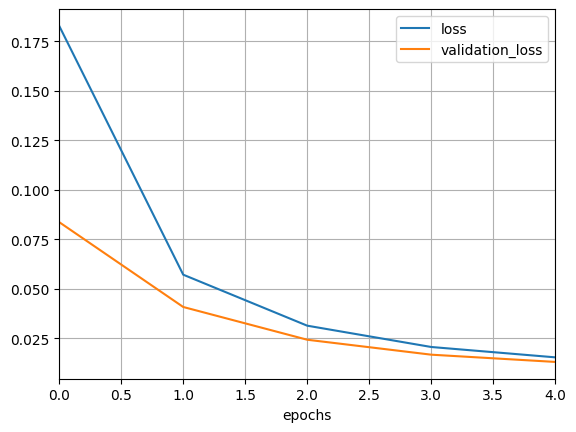

In [41]:
plot_function(history_linear)

In [42]:
score = model_linear.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print(f'Test MSE: ', score[1])

Test loss: 0.013157133013010025
Test MSE:  0.013157133013010025


### 1.5 Simple RNN Model

In [43]:
model_simple_rnn = Sequential()
model_simple_rnn.add(SimpleRNN(1, input_shape=[50, 1]))

In [44]:
learning_rate_simple_rnn = 0.001
optimizer_simple_rnn = Adam(learning_rate_simple_rnn)
model_simple_rnn.compile(loss='mean_squared_error', optimizer=optimizer_simple_rnn, metrics=['mean_squared_error'])

In [45]:
history_simple_rnn = model_simple_rnn.fit(X_train, y_train, epochs=no_training_epochs, validation_data=[X_valid, y_valid])

Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.2891 - mean_squared_error: 0.2891 - val_loss: 0.2335 - val_mean_squared_error: 0.2335
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1677 - mean_squared_error: 0.1677 - val_loss: 0.1187 - val_mean_squared_error: 0.1187
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0797 - mean_squared_error: 0.0797 - val_loss: 0.0570 - val_mean_squared_error: 0.0570
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0448 - mean_squared_error: 0.0448 - val_loss: 0.0388 - val_mean_squared_error: 0.0388
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0356 - mean_squared_error: 0.0356 - val_loss: 0.0337 - val_mean_squared_error: 0.0337


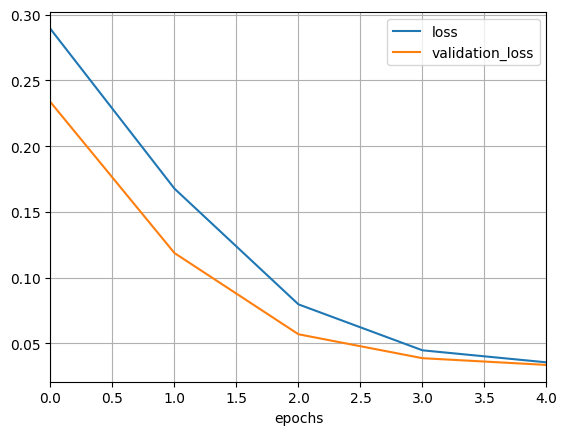

In [46]:
plot_function(history_simple_rnn)

### 1.5 Deep RNN Model

In [47]:
model_deep_rnn = Sequential()
model_deep_rnn.add(SimpleRNN(20, return_sequences = True, input_shape=[50, 1]))
model_deep_rnn.add(SimpleRNN(20, return_sequences = True))
model_deep_rnn.add(SimpleRNN(1, input_shape=[50, 1]))

In [48]:
learning_rate_deep_rnn = 0.001
optimizer_deep_rnn = Adam(learning_rate_deep_rnn)
model_deep_rnn.compile(loss='mean_squared_error', optimizer=optimizer_deep_rnn, metrics=['mean_squared_error'])

In [49]:
history_deep_rnn = model_deep_rnn.fit(X_train, y_train, epochs=no_training_epochs, validation_data=[X_valid, y_valid])

Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - loss: 0.0321 - mean_squared_error: 0.0321 - val_loss: 0.0066 - val_mean_squared_error: 0.0066
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0057 - mean_squared_error: 0.0057 - val_loss: 0.0049 - val_mean_squared_error: 0.0049
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0046 - mean_squared_error: 0.0046 - val_loss: 0.0044 - val_mean_squared_error: 0.0044
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0039 - mean_squared_error: 0.0039 - val_loss: 0.0052 - val_mean_squared_error: 0.0052
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0037 - mean_squared_error: 0.0037 - val_loss: 0.0032 - val_mean_squared_error: 0.0032


In [50]:
score = model_deep_rnn.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print(f'Test MSE: ', score[1])

Test loss: 0.0033461323473602533
Test MSE:  0.0033461323473602533


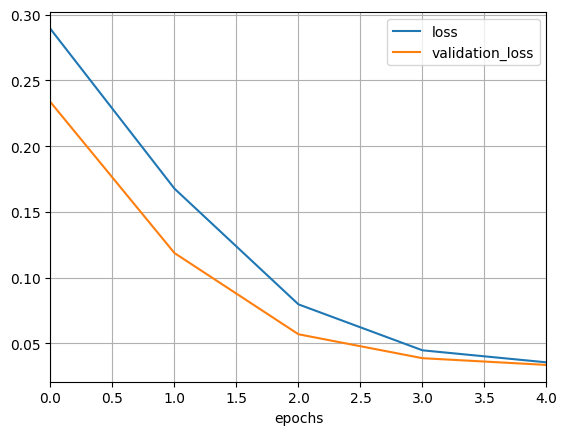

In [51]:
plot_function(history_simple_rnn)

## Exercise 2 - The movie review




Based on the written rewiev, classify if the movie if good or bad

### 2.0 - Import libraries

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding, SimpleRNN, GRU, Input
from tensorflow.keras.optimizers import Adam

### 2.1 - Load dataset

In [54]:
(X_train, y_train), (X_test, y_test) = keras.datasets.imdb.load_data()

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


### 2.2 - Dataset examination

In [55]:
word_index = keras.datasets.imdb.get_word_index()
id_to_word = {id_ + 3:word for word, id_ in word_index.items()}
for id_, token in enumerate(("<pad>", "<sos>", "<unk>")):
  id_to_word[id_] = token

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step


In [56]:
single_sequence = " ".join([id_to_word[id_] for id_ in X_train[0][:]])

In [57]:
single_sequence

"<sos> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert redford's is an amazing actor and now the same being director norman's father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for retail and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also congratulations to the two little boy's that played the part's of norman and paul they were just brilliant children are often left out of the praising list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and shou

In [58]:
max_length = 150  # Define the maximum length of a review
X_train = keras.preprocessing.sequence.pad_sequences(X_train, maxlen=max_length, padding='post', truncating='post', value=0)
X_test = keras.preprocessing.sequence.pad_sequences(X_test, maxlen=max_length, padding='post', truncating='post', value=0)

In [65]:
embed_size = 128
vocabulary_size = 1000

model = keras.models.Sequential([
    keras.layers.Embedding(vocabulary_size, embed_size,
                           input_shape=[None]),
    keras.layers.SimpleRNN(128, return_sequences=True),
    keras.layers.SimpleRNN(128),
    keras.layers.Dense(1, activation='sigmoid')
    ])


In [66]:
optimizer = Adam(learning_rate = 0.001)

In [67]:
model.compile(loss="binary_crossentropy", optimizer=optimizer, metrics=["accuracy"])

In [68]:
history = model.fit(X_train, y_train, epochs=5, validation_split=0.2)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - accuracy: 0.4961 - loss: 0.7026 - val_accuracy: 0.5062 - val_loss: 0.6951
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.5006 - loss: 0.6957 - val_accuracy: 0.4938 - val_loss: 0.6935
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.5088 - loss: 0.6950 - val_accuracy: 0.5460 - val_loss: 0.6882
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.5457 - loss: 0.6883 - val_accuracy: 0.5520 - val_loss: 0.6850
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.5412 - loss: 0.6876 - val_accuracy: 0.5602 - val_loss: 0.6757


In [69]:
score = model.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print(f'Test accuracy: ', score[1]*100, "%")

Test loss: 0.6771460175514221
Test accuracy:  55.21199703216553 %


TASK: Modify structure, change the core of the network from RNN to LTSM and GRU. Compare the results

Entrenando modelo LSTM...
Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.5771 - loss: 0.6777 - val_accuracy: 0.6164 - val_loss: 0.6600
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.6571 - loss: 0.6212 - val_accuracy: 0.6544 - val_loss: 0.6185
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.6930 - loss: 0.5918 - val_accuracy: 0.6874 - val_loss: 0.5781
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.7640 - loss: 0.4993 - val_accuracy: 0.7864 - val_loss: 0.4676
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.8071 - loss: 0.4300 - val_accuracy: 0.7822 - val_loss: 0.4587
Test accuracy LSTM: 79.19 %


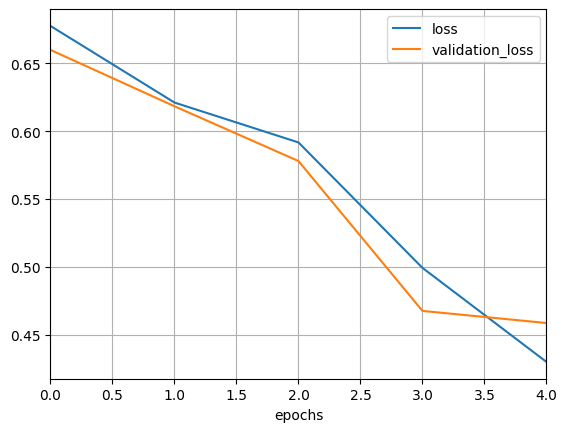

In [73]:
# Definición del modelo LSTM
embed_size = 128
vocabulary_size = 1000

model_lstm = Sequential([
    Input(shape=[None]),
    Embedding(vocabulary_size, embed_size),
    LSTM(128, return_sequences=True), # Cambiamos SimpleRNN por LSTM
    LSTM(128),                        # Cambiamos SimpleRNN por LSTM
    Dense(1, activation='sigmoid')
])

# Compilación y entrenamiento
optimizer_lstm = Adam(learning_rate = 0.001)
model_lstm.compile(loss="binary_crossentropy", optimizer=optimizer_lstm, metrics=["accuracy"])

print("Entrenando modelo LSTM...")
history_lstm = model_lstm.fit(X_train, y_train, epochs=5, validation_split=0.2)

# Evaluación
score_lstm = model_lstm.evaluate(X_test, y_test, verbose=0)
print(f'Test accuracy LSTM: {score_lstm[1]*100:.2f} %')

plot_function(history_lstm)

Entrenando modelo GRU...
Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.5745 - loss: 0.6732 - val_accuracy: 0.6862 - val_loss: 0.6070
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.7176 - loss: 0.5571 - val_accuracy: 0.7380 - val_loss: 0.5268
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.8038 - loss: 0.4261 - val_accuracy: 0.8240 - val_loss: 0.4025
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.8357 - loss: 0.3734 - val_accuracy: 0.8290 - val_loss: 0.3814
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.8469 - loss: 0.3440 - val_accuracy: 0.8342 - val_loss: 0.3853
Test accuracy GRU: 83.41 %


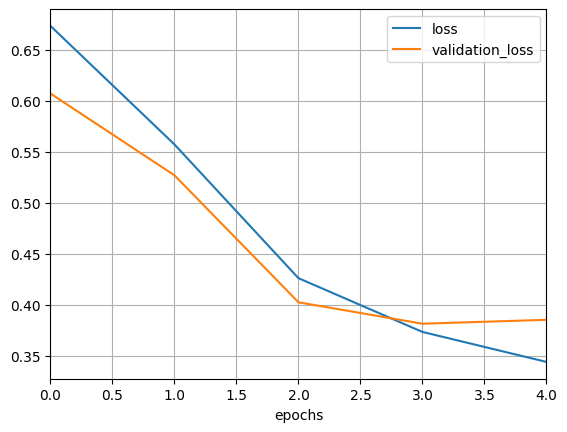

In [74]:
# Definición del modelo GRU
model_gru = Sequential([
    Input(shape=[None]),
    Embedding(vocabulary_size, embed_size),
    GRU(128, return_sequences=True),  # Cambiamos LSTM/SimpleRNN por GRU
    GRU(128),                         # Cambiamos LSTM/SimpleRNN por GRU
    Dense(1, activation='sigmoid')
])

# Compilación y entrenamiento
optimizer_gru = Adam(learning_rate = 0.001)
model_gru.compile(loss="binary_crossentropy", optimizer=optimizer_gru, metrics=["accuracy"])

print("Entrenando modelo GRU...")
history_gru = model_gru.fit(X_train, y_train, epochs=5, validation_split=0.2)

# Evaluación
score_gru = model_gru.evaluate(X_test, y_test, verbose=0)
print(f'Test accuracy GRU: {score_gru[1]*100:.2f} %')

plot_function(history_gru)